# 프로젝트 명: Spaceship Titanic - 누가누가 잘살아나갔을까.. 예측해보자
> 분석 목적: 차원이동된 승객을 구해보자
평가 지표: Accuracy (정확도)

### 라이브러리, 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_PATH = '/home/jovyan/work/0407data/'

In [2]:
train = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))
submission = pd.read_csv(os.path.join(DATA_PATH, 'sample_submission.csv'))

In [6]:
print(f"Train Shape : {train.shape}")
print(f"Test Shape : {test.shape}")
train.head()

Train Shape : (8693, 14)
Test Shape : (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [7]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [4]:
print(train.shape) 
print(test.shape) 

submission.head()

(8693, 14)
(4277, 13)


,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


### 결측치 파악하기

In [8]:
null_counts = train.isnull().sum()
null_percent = (train.isnull().sum() / len(train)) * 100

In [9]:
null_df = pd.DataFrame({'null_count': null_counts, 'null_percent': null_percent})
print(null_df[null_df['null_count'] > 0].sort_values(by='null_count', ascending=False))

              null_count  null_percent
CryoSleep            217      2.496261
ShoppingMall         208      2.392730
VIP                  203      2.335212
HomePlanet           201      2.312205
Name                 200      2.300702
Cabin                199      2.289198
VRDeck               188      2.162660
FoodCourt            183      2.105142
Spa                  183      2.105142
Destination          182      2.093639
RoomService          181      2.082135
Age                  179      2.059128


In [10]:
import missingno as msno
msno.matrix(train)
plt.show()

ModuleNotFoundError: No module named 'missingno'

In [11]:
!pip install missingno

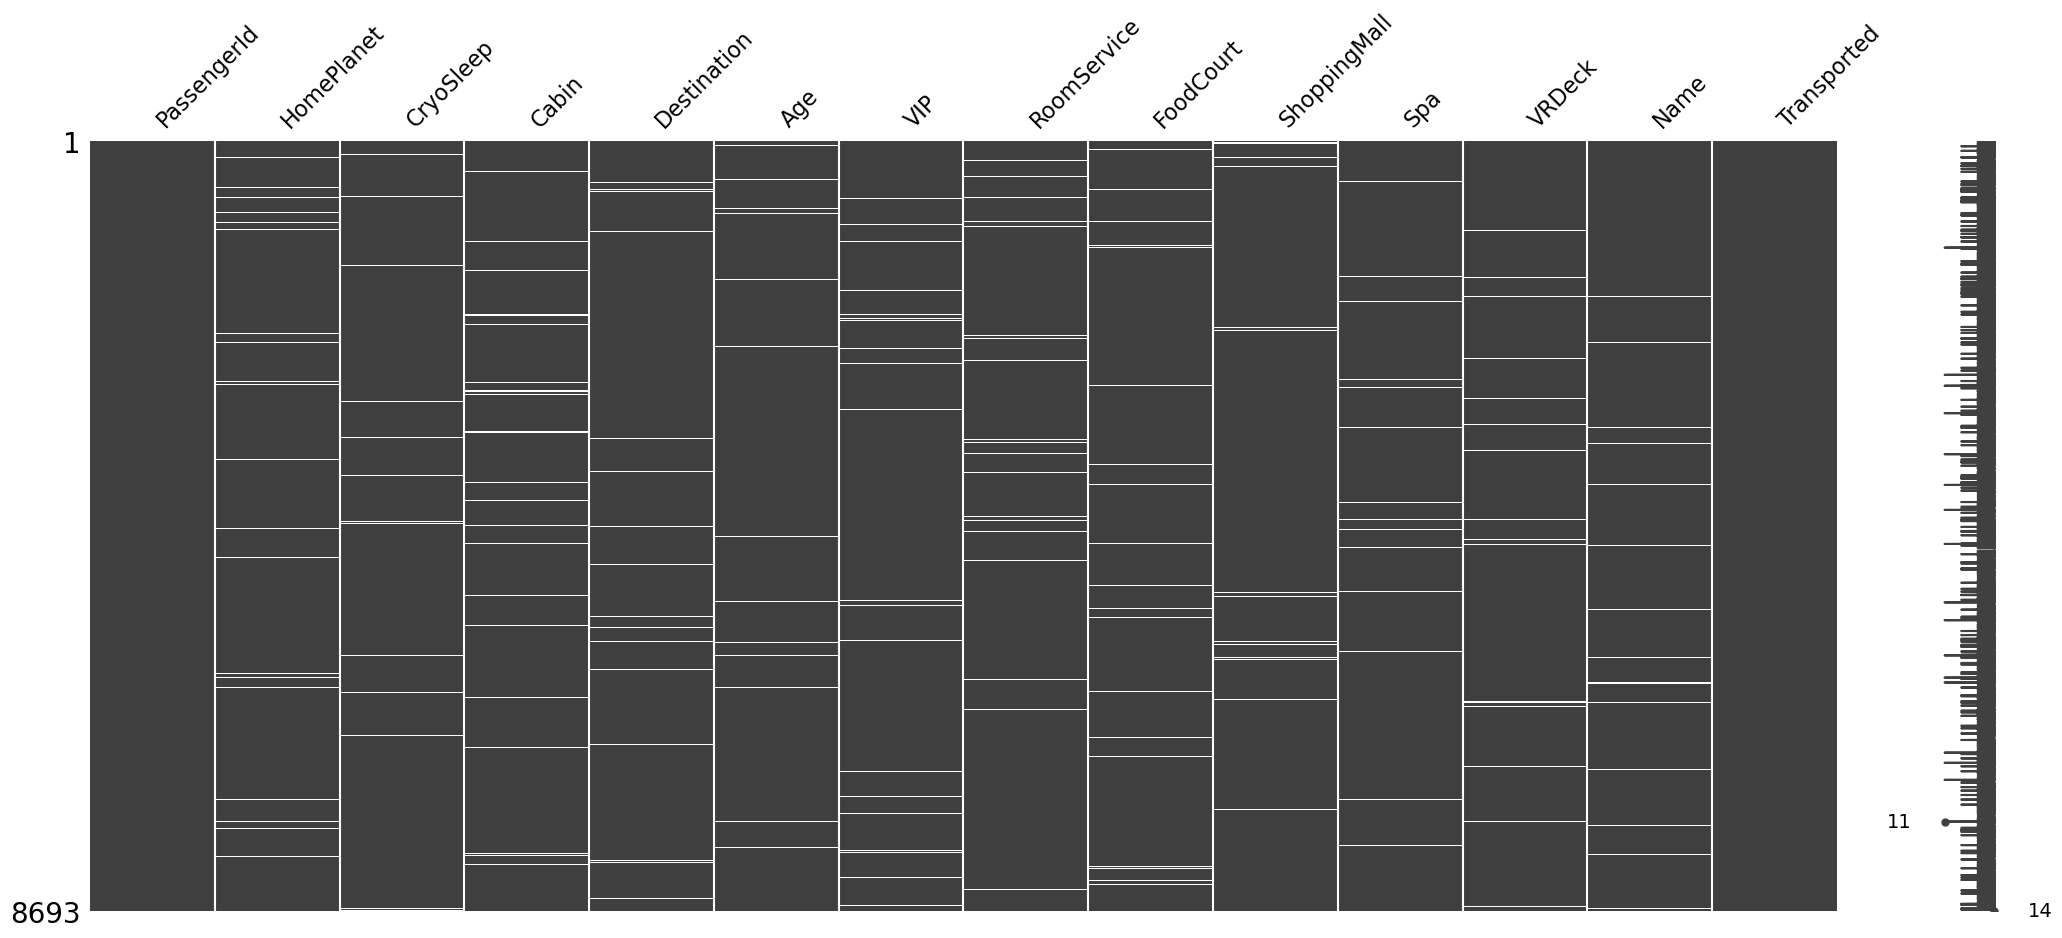

In [12]:
import missingno as msno
msno.matrix(train)
plt.show()

승객이나 차원이동 구간은 올검.. 중간중간 사다리처럼 보이는 흰줄이 결측치를 나타낸다.
근대 이것만 보고는 솔직히 어디가 비었는지 잘모르겠다. 시각화를하면 데이터 분석이 더잘되야되는데 오히려 역효과인것 같다...

In [14]:
null_count = train.isnull().sum()
null_percent = (train.isnull().sum() / len(train)) * 100
null_report = pd.DataFrame({
    'Missing Values': null_count,
    'Percentage (%)': null_percent
})
print(null_report[null_report['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False))

              Missing Values  Percentage (%)
CryoSleep                217        2.496261
ShoppingMall             208        2.392730
VIP                      203        2.335212
HomePlanet               201        2.312205
Name                     200        2.300702
Cabin                    199        2.289198
VRDeck                   188        2.162660
FoodCourt                183        2.105142
Spa                      183        2.105142
Destination              182        2.093639
RoomService              181        2.082135
Age                      179        2.059128


이게 시각화지.. 乃 비어있는 구간이 생각보다 적음으로 데이터를 날리기보단 부분 보완해서 사용해야겠다.
그루들의 뻐꾸기로 동면중일때 푸드코트 사용비중이 0인걸 이야기했는데 그부분을 파헤쳐보자.

In [15]:
# 지출관련 피쳐
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

In [16]:
#동면 중인 사람을 true로 하고 지출을 0으로 채워놓기
for col in spending_cols:
    train.loc[(train['CryoSleep'] == True) & (train[col].isnull()), col] = 0
    test.loc[(test['CryoSleep'] == True) & (test[col].isnull()), col] = 0

In [ ]:
반대로 동면이 아닌사람은 애매한게 돈이없어서 돈을 안썻을수도 있어서 동면중인 사람처럼 편하게 지출0으로 채우자 같은 a=b 같은 방식으로는 
힘들것 같다...머리아프다
일단은 지출이 있으면 동면이 아닌거니까 거기부터 시작해보자

In [17]:
train.loc[(train['CryoSleep'].isnull()) & (train[spending_cols].sum(axis=1) > 0), 'CryoSleep'] = False
test.loc[(test['CryoSleep'].isnull()) & (test[spending_cols].sum(axis=1) > 0), 'CryoSleep'] = False

지출한 사람을 어떻게 할지 평균값이 있나 찾아보니까 중앙값이란게 있다는걸 알았다.
지출한 사람들의 결측치는 중앙값으로 설정해서 채워내보자

In [18]:
for col in spending_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(test[col].median())
print("결측치 채우기 완료")

결측치 채우기 완료


전처리 과정은 이정도로 하고 후에 혹시 점수가 생각보다 적게 나온다면 추가 전처리 과정을 해야겠다.
나중일은 미래의 나에게...

> 데이터는 세팅이되었고 이제 본격적인 추리를 시작하자

일단 cabin 객실번호인거 같은데 3가지로 나눠진걸 찾아보니 층수, 방번호, 좌현(p), 우현(s)으로 나눠진다
굳이 정보를 p,s 로 나눈걸보니 선체에 사고흔적이 없다고는 했지만 공간이상파동이 배의 좌현 or 우현 중 편향되게 발생되었다면 객실의 위치에 따라 실종자가 한쪽으로 치우치게
발생되었을거 같으므로 그걸 수치화해서 파악해봅시당ㅇㅇ


In [19]:
#  Cabin '/' 기준으로 쪼개서 새로운 피쳐 3개 만들기
# 결측치가 있으면 쪼갤 수 없으므로 'None/None/None'으로 임시 처리 후 진행합니다.(이것때매 오류계속남..)
train['Cabin'] = train['Cabin'].fillna('None/None/None')
test['Cabin'] = test['Cabin'].fillna('None/None/None')

In [20]:
# 데크:층수 카빈넘:방번호 사이드: 좌현우현
train[['Deck', 'Cabin_num', 'Side']] = train['Cabin'].str.split('/', expand=True)
test[['Deck', 'Cabin_num', 'Side']] = test['Cabin'].str.split('/', expand=True)

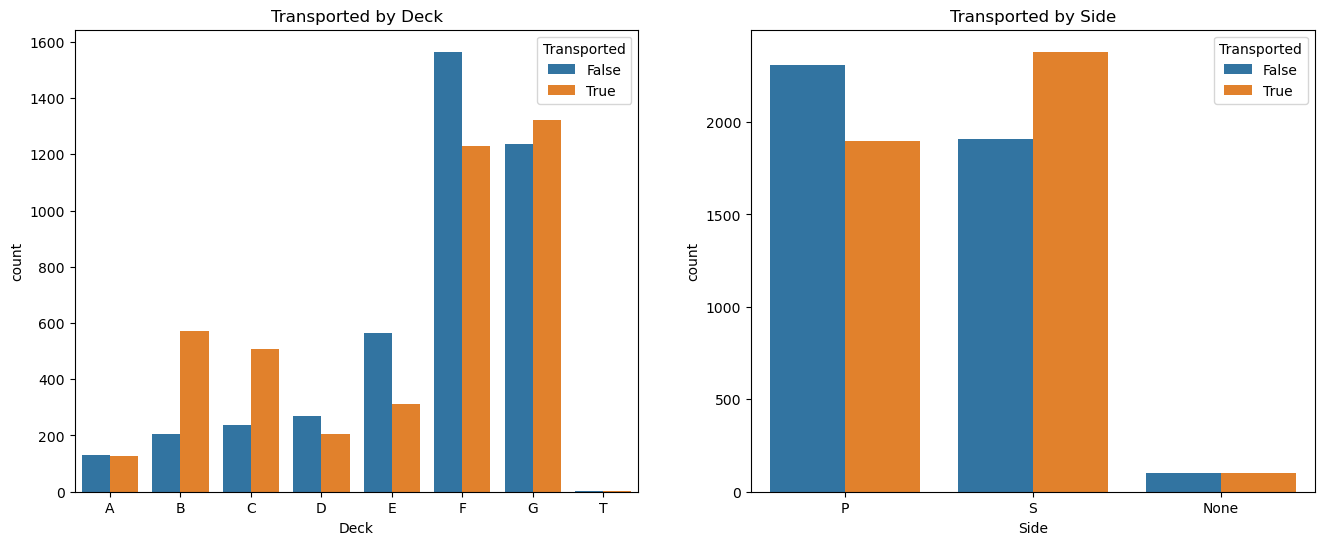

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=train, x='Deck', hue='Transported', order=['A','B','C','D','E','F','G','T'], ax=axes[0])
axes[0].set_title('Transported by Deck')

sns.countplot(data=train, x='Side', hue='Transported', ax=axes[1])
axes[1].set_title('Transported by Side')

plt.show()

데크 표를 봤을때 추리할수있는점은
A로 갈수록 vip 층일 확률이높다 비쌀수록 승객수가 적은 좋은 객실일 확률이크고 뒤로 fg로 갈수록 사람수가 많은걸보니 일반객실인걸 추리할수 있었다.
그런대도 특이한점은 b ,c 중상 부자들 층이 생존자보다 실종자 수치가 압도적으로 높게 나왔다는것, 실종자수를 카운트하면 일반객실 f,g가 많긴하지만 퍼센트로 보면
b,c 쪽에 이상현상의 직격탄을 받은것 같다 이부분을 나중에 중점적으로 머신러닝하면 좋은결과 값이 나올것 같다
이와 같이 그렇게 큰차이로 보이지는 않지만 좌현보다(p) 우현(s)이 실종자비율이 큰걸보니 이상현상이 오른쪽 위주로 발생된걸 추리할수있었다.    

### 추리자료 수치화 하기 
이제 우리가 김전일마냥 추리한 자료를 러닝머신하기위해 데크abcd층 p,s 우현좌현을 데이터화 해줍시다.!!!

In [22]:
from sklearn.preprocessing import LabelEncoder

# 1. 러닝머신에 쓸 귀중한 자료 수치화
categorical_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

In [23]:
for col in categorical_cols:
    le = LabelEncoder()
    # 데이터 타입을 문자열로 확실히 바꾼 뒤 번역
    train[col] = le.fit_transform(train[col].astype(str))  #fit 사용하여 번역기 창조하기,.
    test[col] = le.transform(test[col].astype(str))

In [24]:
# 러닝중 불필요한 나머지 글자 피쳐들을 처리해주자
train_df = train.drop(['PassengerId', 'Cabin', 'Name', 'Cabin_num'], axis=1)
test_df = test.drop(['PassengerId', 'Cabin', 'Name', 'Cabin_num'], axis=1)

train_df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Side
0,1,0,2,39.0,0,0.0,0.0,0.0,0.0,0.0,False,1,1
1,0,0,2,24.0,0,109.0,9.0,25.0,549.0,44.0,True,5,2
2,1,0,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,0,2
3,1,0,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,0,2
4,0,0,2,16.0,0,303.0,70.0,151.0,565.0,2.0,True,5,2


## 모델 머신러닝
드디어 김전일마냥 추리한것들로 머신러닝을 시켜보자
앞서 수많은 노예들을 대려다 썻지만 목표확보의 실패한바 이번 퀘스트에서는 불긴한 단어는 쓰지않겠다.
자료 조사를 하며 기존 코드를 탐독했을때 xgboost 이친구가 많이 쓰이는걸 보았다,
아직 한번도 사용해보진 않았지만 그동안 어셈블한 노예들 랜덤포레스트, lgbm, 기타등등이 과적합의 오류의빠진걸 봣음으로
새로운 친구로 시작해봅시다.!!!!!!!!

In [25]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

ModuleNotFoundError: No module named 'xgboost'

In [26]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 46.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 40.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]


In [27]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [30]:
# 1. 학습 데이터와 정답(Target) 분리
X = train_df.drop(['Transported'], axis=1)
y = train_df['Transported'].astype(int) ## <<<인트로 쓰면 true/false로 알아서 변환되는 개꿀팁..
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42) #8:2 국룰
# 새로운친구 학습강도 설정
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)


val_preds = model.predict(X_val)
accuracy = accuracy_score(y_val, val_preds)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7941


....첫술의 배부를수는없다 강도를더 높혀서 채직질을 해보자

In [31]:
model = XGBClassifier(
    n_estimators=1000,     
    learning_rate=0.01,     
    max_depth=7,           
    random_state=42,
    eval_metric='logloss'   
)

model.fit(X_train, y_train)


val_preds = model.predict(X_val)
accuracy = accuracy_score(y_val, val_preds)

print(f" 업그레이드 후 정확도: {accuracy:.4f}")

 업그레이드 후 정확도: 0.7930


아 아까 돈안쓴사람 동면중인 사람을 타겟으로 해서 다시 돌려보자..

In [32]:
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train_df['TotalSpending'] = train_df[spending_cols].sum(axis=1)
test_df['TotalSpending'] = test_df[spending_cols].sum(axis=1)

In [33]:
train_df['NoSpending'] = (train_df['TotalSpending'] == 0).astype(int)
test_df['NoSpending'] = (test_df['TotalSpending'] == 0).astype(int)

In [34]:
model = XGBClassifier(
    n_estimators=300,        
    learning_rate=0.05,
    max_depth=5,            
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)
val_preds = model.predict(X_val)
accuracy = accuracy_score(y_val, val_preds)

print(f"정확도: {accuracy:.4f}")

정확도: 0.7849


처음부터 다시 시작해보자.

>이번에는 다른 상위권 코더들의 머신러닝을 써보고 결측치는 잘한것같고 데크 나눈것도 괜찬았는데 여기까지는 그대로하고
아까 자료 탐독할때 혼자 탑승한고객이 많이 죽었다는걸 봤는데 그게 힌트인것같다 가족단위와 아닌그룹 을 어떻게잘 나눠서 학습시켜보자

# 2차 도전!!!!!!!
##  목표
 실종에 영향을 미친 결정적인 요인을 찾아내고, 고성능 모델인 LightGBM을 활용해 예측 정확도를 높혀보자ㅏㅏㅏ

In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [229]:
DATA_PATH = '/home/jovyan/work/0407data/'

In [230]:
train = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))
submission = pd.read_csv(os.path.join(DATA_PATH, 'sample_submission.csv'))

In [231]:
# 기존에는 트레인과 테스트를 나눴는데 결합해서  데이터를 테스트하는게 성능의 더 좋다는 팁을 보았음..
all_data = pd.concat([train, test], axis=0).reset_index(drop=True)

In [232]:
print(f"전체 데이터 개수: {len(all_data)}")
all_data.head()

전체 데이터 개수: 12970


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


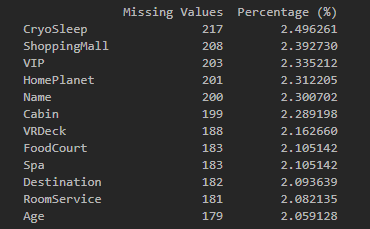

전 프로젝트에서 결측치가 2% 내외인걸 확인했음으로 단순히 평균값을 구해서 결측치를 채우기보다는 좀더 세밀히들어가서
승객들 지출상태등을 기반으로 부족한 부문을 채우는 쪽으로 접근하는게 좋을것 같다.
그중에 이용금액이 0인경우 실제 돈이 없었을수도있고 아니면 데이터가 누락될수도 있음 아니면 중요한 동면상태이거나
우선 0으로 처리한뒤 전체지출내역으로 변수를 만들어서 나가보자..

In [233]:
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

In [234]:
# 결측치를 0으로 채움 (돈을 안 썼다고 가정)
all_data[spending_cols] = all_data[spending_cols].fillna(0)

In [235]:
all_data['TotalSpending'] = all_data[spending_cols].sum(axis=1)
print(f"지출 내역 결측치 개수: \n{all_data[spending_cols].isnull().sum()}")
print(f"TotalSpending 상위 5개: \n{all_data['TotalSpending'].head()}")

지출 내역 결측치 개수: 
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64
TotalSpending 상위 5개: 
0        0.0
1      736.0
2    10383.0
3     5176.0
4     1091.0
Name: TotalSpending, dtype: float64


## 동면상태 이용하기
여기에 cryosleep 이 flase인 사람중 우리가지정한 totalspending <<우주선 지출내역이 발생한 사람은 절대로 동면 상태일수 없으니까
이걸 이용해서 나머지 결측치부분을 채워보자

In [236]:
# 지출이 0보다 크면 cryosleep이 아니여하며
all_data.loc[(all_data['CryoSleep'].isnull()) & (all_data['TotalSpending'] > 0), 'CryoSleep'] = False

print(f"CryoSleep 남은 결측치: {all_data['CryoSleep'].isnull().sum()}개")

CryoSleep 남은 결측치: 136개


여기서 잠깐 생각해볼게 지출내역 합계로만든 변수 '토탈스펜딩'이 승객의 동면 여부나, 지출내역으로 선내의 vip즉 사회적지위를 직,간접적으로 나태낼수 있다
고 생각하며 접근하는게 좋을것같다. 또한 지출여부와 실종여부의 상관 관계도 알아보자

In [237]:
all_data['HasSpent'] = all_data['TotalSpending'] > 0

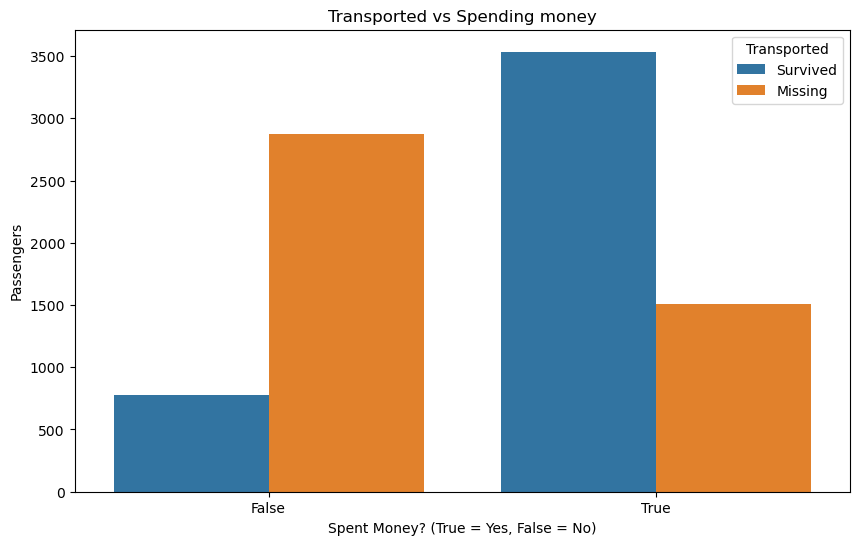

In [238]:
temp_train = all_data[:len(train)].copy()

plt.figure(figsize=(10, 6))
sns.countplot(data=temp_train, x='HasSpent', hue='Transported')
plt.title('Transported vs Spending money')
plt.xlabel('Spent Money? (True = Yes, False = No)')
plt.ylabel('Passengers')
plt.legend(title='Transported', labels=['Survived', 'Missing'])
plt.show()

In [239]:
pivot = temp_train.groupby('HasSpent')['Transported'].mean()
print("--- 지출 여부에 따른 실종 확률 ---")
print(pivot)

--- 지출 여부에 따른 실종 확률 ---
HasSpent
False    0.786477
True     0.298611
Name: Transported, dtype: object


> HasSpent = False (돈 안 쓴 그룹): 주황색(실종)이 생존보다 훨씬높다
> HasSpent = True (돈 쓴 그룹): 반대로 파란색(생존)이 실종보다 높다
>

돈안쓴 사람이 실종확률이 더 높은걸 볼수있다 그럼 동면중이였으니까 사고가 발생했을때 대피를 못한거라고 생각할수도 있다.
반대로 생각하면 마침 식당 이나 여가 시설에서 돈쓰다가 사고가 발생해서 운좋게 대피했을수도 있다고 추론할수있다..?!

## cabin  분석하기
기존에 우리는 카빈이 층 방번호 좌현인지 우현인지 알수 있었다 그것또한 실종관계에 넣으면 좋을것 같아 분석해봅시다..
사고 시점과 승객들의 방 공간 사이의 접점을 알아보자

In [240]:
#Cabin의 결측치를 기존 머신러닝때처럼  'None/None/None'으로
all_data['Cabin'] = all_data['Cabin'].fillna('None/None/None')

In [241]:
temp_cabin = all_data['Cabin'].str.split('/', expand=True)

In [242]:
if temp_cabin.shape[1] == 3:
    all_data[['Deck', 'Cabin_num', 'Side']] = temp_cabin
else:
   
    all_data['Deck'] = temp_cabin[0]
    all_data['Cabin_num'] = temp_cabin[1] if temp_cabin.shape[1] > 1 else 'None'
    all_data['Side'] = temp_cabin[2] if temp_cabin.shape[1] > 2 else 'None'

# 4. 결과 확인
print(all_data[['Deck', 'Cabin_num', 'Side']].head())

  Deck Cabin_num Side
0    B         0    P
1    F         0    S
2    A         0    S
3    A         0    S
4    F         1    S


결측치를 채워넣었으니 이제 시각화해서 내 추리가 맞는지 다시한번 확인해보자..

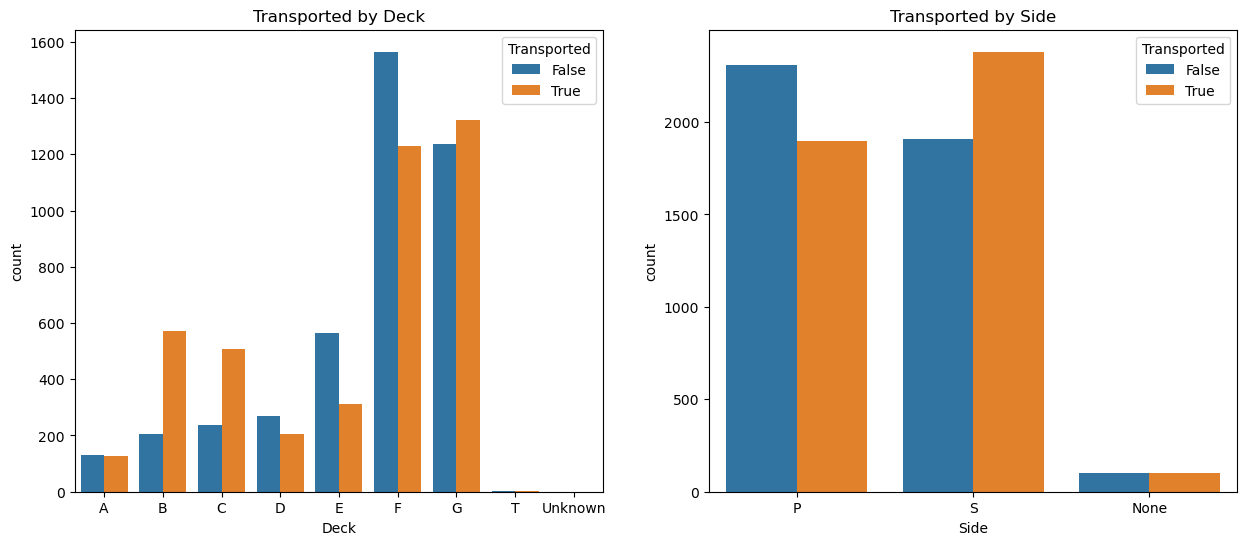

In [243]:
temp_train = all_data[:len(train)].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.countplot(data=temp_train, x='Deck', hue='Transported', 
              order=['A','B','C','D','E','F','G','T','Unknown'], ax=axes[0])
axes[0].set_title('Transported by Deck')
sns.countplot(data=temp_train, x='Side', hue='Transported', ax=axes[1])
axes[1].set_title('Transported by Side')

plt.show()

데크 표를 봤을때 추리할수있는점은
A로 갈수록 vip 층일 확률이높다 비쌀수록 승객수가 적은 좋은 객실일 확률이크고 뒤로 fg로 갈수록 사람수가 많은걸보니 일반객실인걸 추리할수 있었다.
그런대도 특이한점은 b ,c 중상 부자들 층이 생존자보다 실종자 수치가 압도적으로 높게 나왔다는것, 실종자수를 카운트하면 일반객실 f,g가 많긴하지만 퍼센트로 보면
b,c 쪽에 이상현상의 직격탄을 받은것 같다 이부분을 나중에 중점적으로 머신러닝하면 좋은결과 값이 나올것 같다
이와 같이 그렇게 큰차이로 보이지는 않지만 좌현보다(p) 우현(s)이 실종자비율이 큰걸보니 이상현상이 오른쪽 위주로 발생된걸 추리할수있었다. 

이건 기존 위에서 했던 러신머닝과 같은 결과값이 나왔다. 


* 마지막으로 이전 러닝에서는 안했던 가족단위까지 분석해보고 러신머닝을 해보자

*승객은 개인이 아닌 단체나 가족 단위로 탑승했을 가능성이 크다
`PassengerId`의 앞자리 번호를 통해 그룹 정보를 추출하고, (0001_01,0001_02..등등) \
그룹의 인원수(`GroupSize`)를 계산하여 함께 탑승한 인원이 실종에 미치는 영향을 분석해보자.

In [244]:
all_data['Group'] = all_data['PassengerId'].apply(lambda x: x.split('_')[0])

In [245]:
all_data['GroupSize'] = all_data.groupby('Group')['Group'].transform('count')

In [246]:
# 이름에서 성 last name만 호출해서 가족관계를 파악, 그리고 이름이 결측치인경우 언노운으로 처리
all_data['Name'] = all_data['Name'].fillna('Unknown Unknown')
all_data['LastName'] = all_data['Name'].str.split().str[-1]

In [247]:
print(all_data[['PassengerId', 'Group', 'GroupSize', 'LastName']].head())

  PassengerId Group  GroupSize     LastName
0     0001_01  0001          1    Ofracculy
1     0002_01  0002          1        Vines
2     0003_01  0003          2       Susent
3     0003_02  0003          2       Susent
4     0004_01  0004          1  Santantines


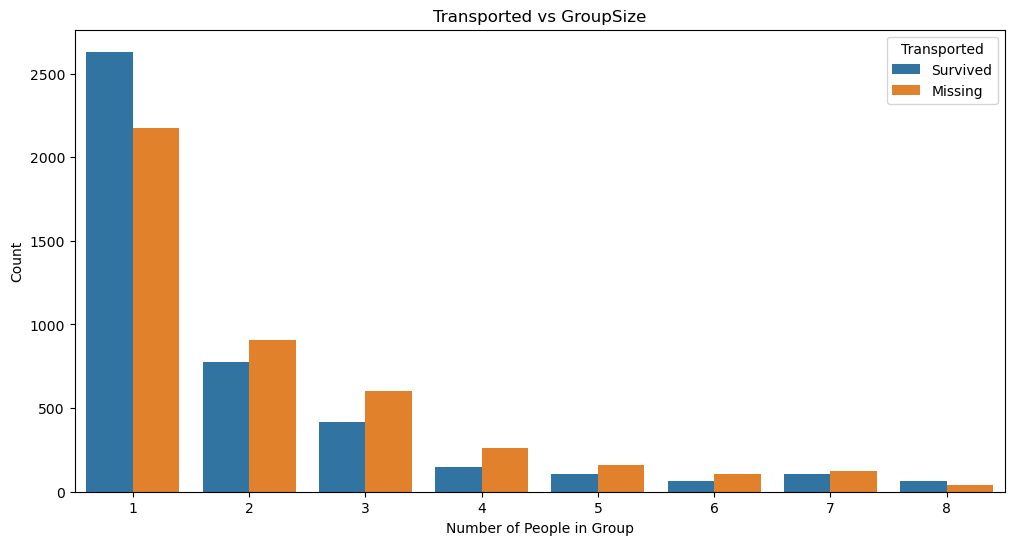

In [248]:
temp_train = all_data[:len(train)].copy()

plt.figure(figsize=(12, 6))

sns.countplot(data=temp_train, x='GroupSize', hue='Transported')
plt.title('Transported vs GroupSize')
plt.xlabel('Number of People in Group')
plt.ylabel('Count')
plt.legend(title='Transported', labels=['Survived', 'Missing'])
plt.show()

In [249]:
group_prob = temp_train.groupby('GroupSize')['Transported'].mean()
print("--- 그룹 규모별 실종 확률 ---")
print(group_prob)

--- 그룹 규모별 실종 확률 ---
GroupSize
1    0.452445
2     0.53805
3    0.593137
4    0.640777
5    0.592453
6    0.614943
7    0.541126
8    0.394231
Name: Transported, dtype: object


단독 승객보다 2~4인 가족이 높은 실종비율을 보여주고있다\
아니 생각한거랑은 좀.. 다르게 나왔다.. 가족끼리가 더 똘똘뭉쳐서 생존할줄알았는데.. 반대로 나오긴 했지만\
머신 러닝에는 유용한 자료로 쓰일것이다.. 헛되지 않기를..

## 머신러닝전 마지막 데이터 수치화 하기!!!!!
모델이 데이터 계산할수 있게 문자열을 인트로 변환 시키자\
그리고 학습할때 필요없는 카테고리도 삭제시키자.

In [250]:
categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'Group']

In [251]:
# Labelencoder를 사용하면 혹시 남아있는 결측치를 문자열로 강제 변화할때 좋음 함수로 추천받아 사용해보자
le = LabelEncoder()
for col in categorical_features:
    all_data[col] = le.fit_transform(all_data[col].astype(str))

In [252]:
drop_cols = ['PassengerId', 'Cabin', 'Name', 'LastName', 'Cabin_num']

In [253]:
print("수치화 완료된 데이터 샘플 :")
display(all_data.drop(columns=[col for col in drop_cols if col in all_data.columns]).head())

수치화 완료된 데이터 샘플 :


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,TotalSpending,HasSpent,Deck,Side,Group,GroupSize
0,1,0,2,39.0,0,0.0,0.0,0.0,0.0,0.0,False,0.0,False,1,1,0,1
1,0,0,2,24.0,0,109.0,9.0,25.0,549.0,44.0,True,736.0,True,5,2,1,1
2,1,0,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,10383.0,True,0,2,2,2
3,1,0,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,5176.0,True,0,2,2,2
4,0,0,2,16.0,0,303.0,70.0,151.0,565.0,2.0,True,1091.0,True,5,2,3,1


In [254]:
categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'Group']

In [262]:
le = LabelEncoder()
for col in categorical_features:
    all_data[col] = le.fit_transform(all_data[col].astype(str))

# [핵심] 학습에 쓸 데이터 다시 정리
train_df = all_data[:len(train)].copy()
test_df = all_data[len(train):].copy()

# 'Group'은 살리되, 'Name'이나 'Cabin_num'처럼 너무 자잘한 것만 버립니다.
drop_cols = ['PassengerId', 'Cabin', 'Name', 'LastName', 'Cabin_num']
X = train_df.drop(columns=drop_cols + ['Transported'])
y = train_df['Transported'].astype(int)
X_test = test_df.drop(columns=drop_cols + ['Transported'])

## 드디어 모델 러닝 그동안의 추리의 검증시간!!
이번에는 고위 득점자들이 많이사용한 LightGBM 으로 러신머닝을 해볼꺼다\
학습데이터는 국룰인 8:2로 나누고 제발.. 한번에 가보자

In [263]:
train_final = all_data[:len(train)].copy()
test_final = all_data[len(train):].copy()

In [264]:
X = train_final.drop(columns=[col for col in drop_cols if col in train_final.columns])
X = X.drop(columns=['Transported']) # 정답은 드랍하고 ㄱㄱ싱
y = train_final['Transported'].astype(int)

In [265]:
# 테스트 데이터 설정
X_test = test_final.drop(columns=[col for col in drop_cols if col in test_final.columns])
X_test = X_test.drop(columns=['Transported'])

In [269]:
#  훈련 데이터와 검증 데이터로 분리  무적의 8:2
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

In [278]:
lgb_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=7,            # 다시 조금 깊게 (데이터 패턴 파악용)
    num_leaves=50,          # 나무의 폭을 넓힘
    min_child_samples=25,   # 너무 잘게 쪼개지지 않게 방어
    feature_fraction=0.8,   # 학습 시 컬럼의 80%만 무작위 사용 (과적합 방지)
    random_state=42,
    verbose=-1
)

lgb_model.fit(X, y) # 이번엔 전체 데이터로 학습 (검증셋 나누지 않고 화력 집중)

,boosting_type,'gbdt'
,num_leaves,50
,max_depth,7
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,25


In [279]:
val_preds = lgb_model.predict(X_val)
accuracy = accuracy_score(y_val, val_preds)

print(f"\n✨ 최종 검증 정확도(Validation Accuracy): {accuracy:.4f}")


✨ 최종 검증 정확도(Validation Accuracy): 0.8755


In [277]:
final_preds = lgb_model.predict(X_test)
submission['Transported'] = final_preds.astype(bool)
submission.to_csv('plzzz.csv', index=False)
print("✅ 최종 제출 파일 생성 완료!")
print(submission.head())

✅ 최종 제출 파일 생성 완료!
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01        False


In [272]:
lgb_model = LGBMClassifier(
    n_estimators=1000, 
    learning_rate=0.01, 
    max_depth=7, 
    random_state=42,
    verbose=-1 # 불필요한 로그 출력 방지
)

lgb_model.fit(
    X_train, y_train, 
    eval_set=[(X_val, y_val)], 
    eval_metric='binary_logloss'
)
#가보자잇ㅅㅅㅅㅅㅅㅅㅅㅅㅅ

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,7
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [273]:
val_preds = lgb_model.predict(X_val)
accuracy = accuracy_score(y_val, val_preds)

print(f"\n✨ 최종 검증 정확도(Validation Accuracy): {accuracy:.4f}")


✨ 최종 검증 정확도(Validation Accuracy): 0.7999


In [274]:
lgb_model = LGBMClassifier(
    n_estimators=2000, 
    learning_rate=0.01, 
    max_depth=10, 
    random_state=42,
    verbose=-1 # 불필요한 로그 출력 방지
)
lgb_model.fit(
    X_train, y_train, 
    eval_set=[(X_val, y_val)], 
    eval_metric='binary_logloss'
)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.01
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


과적합의 늪에 빠졌다.. 오늘도 저번과 같이 805의 벽은 높았다...할아버지의 명예를 지키지못하고 추리 패배.

# 프로젝트 회고
추리를 요약해보겠습니다 예측이라하지요.

*승객의 개인적 특성보다 사고당시 활동여부({ex)동면,지출활동)와 물리적 위치(Deck,side) 층이나 좌현 우현등이 실종에 결정적인 영향을 미친다는것을 데이터를 통해 증명해냈다.\
또한 첫번째 머신러닝과 다르게 가족관계 여부도 학습시켰는데.. 생각한거랑은 가족관계와 실종관계사이가 다른 결과값이 나왔지만 머신러닝에는 5~10% 결과값 도출에\
영향을 준것 같아 다행이라 생각한다.
저번 퀘스트도 결측치 부분이 미흡해서 110000의 고지를 못넘은것 같다. 역시 아직 agi 시대는 멀었다 잭슨황 이렇게 멍청해서야 알아서 척척척 학습하고 결과를 도출해야지\
언제까지 일일이 떠먹여 줘야 되는건가..누군가 좋은 러신머닝을 만들어서 엔지니어 4~5기 쯤은 결측치를 만들지않아도 사이킷런만 불러와서 \ 척척 해결하는 세대가
금방 오겠지....

>한줄평\
*결측치를 잘 조정해야 결과값이 좋다 아직은 ai는 멍청하니께..